# 01. EDA

Batch 1·2·3의 핵심 4가지(수명 분포, 열화 곡선, ΔQ(V), 충전 조건)만 확인한다. 먼저 `python src/preprocess.py`를 실행해 `data/processed/cells.pkl`을 만든다.

In [1]:
import sys; sys.path.append('../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from features import load_cells, model_cells, FEATURE_SETS
from matplotlib import font_manager

fonts = {f.name for f in font_manager.fontManager.ttflist}      # 설치된 한글 폰트를 고른다

plt.rcParams.update({'font.family': next((f for f in ['AppleGothic', 'NanumGothic', 'Malgun Gothic'] if f in fonts), 'DejaVu Sans'),
                     'axes.unicode_minus': False})
cells, df = load_cells(), model_cells()
df['g'] = df.batch + np.where(df.newstruct, '-new', '-legacy')
print(f'전체 {len(cells)}셀 → 별도 실험·EOL 미도달 제외 후 모델링 대상 {len(df)}셀')
df.groupby('batch').size()

전체 139셀 → 별도 실험·EOL 미도달 제외 후 모델링 대상 119셀


batch
b1    36
b2    39
b3    44
dtype: int64

## 1. Cycle Life 분포

       count    mean    std    min    25%     50%     75%     max
batch                                                            
b1      36.0   788.0  149.0  534.0  681.0   772.0   872.0  1074.0
b2      39.0   566.0  222.0  392.0  440.0   472.0   508.0  1186.0
b3      44.0  1060.0  314.0  541.0  828.0  1006.0  1155.0  1935.0
단수명(<500): 28 / 장수명(>1000): 31


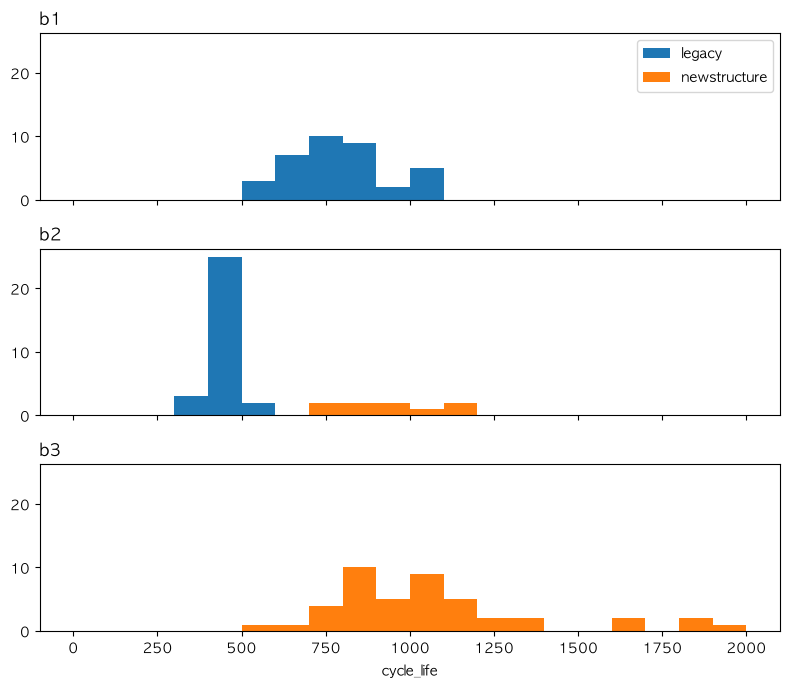

In [2]:
print(df.groupby('batch').cycle_life.describe().round(0))
print('단수명(<500):', (df.cycle_life < 500).sum(), '/ 장수명(>1000):', (df.cycle_life > 1000).sum())
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True, sharey=True)
for ax, (b, g) in zip(axes, df.groupby('batch')):
    ax.hist([g[~g.newstruct].cycle_life, g[g.newstruct].cycle_life], bins=np.arange(0, 2100, 100), stacked=True, label=['legacy', 'newstructure'])
    ax.set_title(b, loc='left')
axes[0].legend(); axes[-1].set_xlabel('cycle_life'); plt.tight_layout()

## 2. 열화 곡선 (수명 진행도 기준)

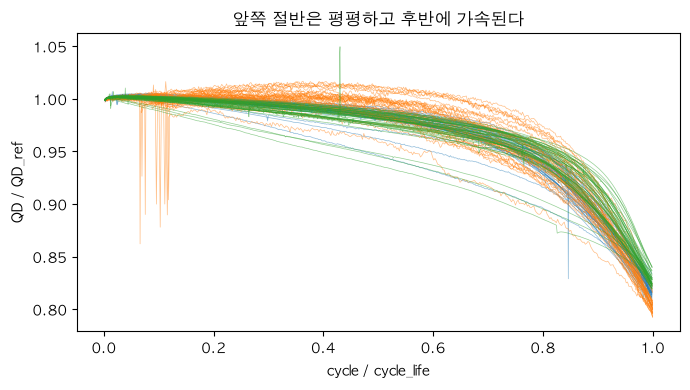

In [3]:
fig, ax = plt.subplots(figsize=(7, 4)); col = {'b1': 'C0', 'b2': 'C1', 'b3': 'C2'}
for _, r in df.iterrows():
    qd = r.qd[:int(r.cycle_life)]; cyc = np.arange(1, len(qd) + 1); ok = (qd > 0.7) & (qd < 1.3) & (cyc >= 2)
    ax.plot(cyc[ok] / r.cycle_life, qd[ok] / np.median(qd[ok][:5]), color=col[r.batch], lw=.5, alpha=.5)
ax.set(xlabel='cycle / cycle_life', ylabel='QD / QD_ref', title='앞쪽 절반은 평평하고 후반에 가속된다'); plt.tight_layout()

## 3. ΔQ(V) = Q100(V) − Q10(V)

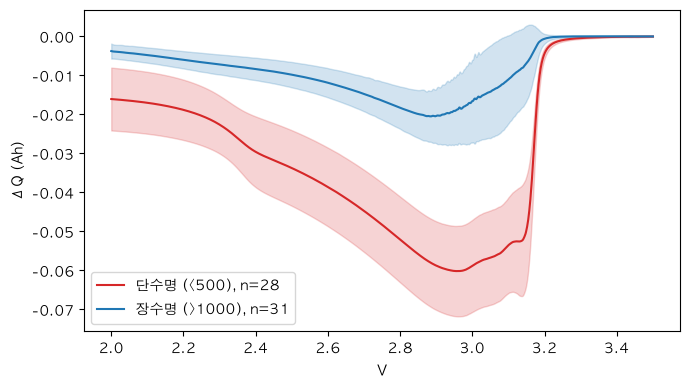

In [4]:
V = np.load('../data/processed/v_grid.npy')
fig, ax = plt.subplots(figsize=(7, 4))
for name, mask, c in [('단수명 (<500)', df.cycle_life < 500, 'C3'), ('장수명 (>1000)', df.cycle_life > 1000, 'C0')]:
    A = np.vstack(df[mask].dq); m, s = A.mean(0), A.std(0)
    ax.plot(V, m, color=c, label=f'{name}, n={len(A)}'); ax.fill_between(V, m - s, m + s, color=c, alpha=.2)
ax.set(xlabel='V', ylabel='ΔQ (Ah)'); ax.legend(); plt.tight_layout()

## 4. 충전 조건과 수명

        mean   std   min    max
batch                          
b1     10.61  0.81  8.89  12.00
b2     10.00  0.01  9.99  10.02
b3     10.00  0.01  9.97  10.01


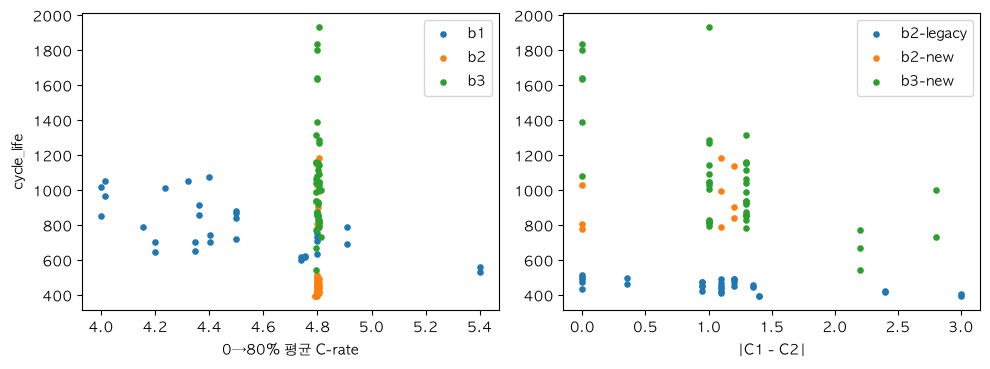

In [5]:
df['t80_min'] = 48 / df.avg_c          # 0→80% 충전 시간(분)
print(df.groupby('batch').t80_min.agg(['mean', 'std', 'min', 'max']).round(2))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for b, g in df.groupby('batch'): axes[0].scatter(g.avg_c, g.cycle_life, s=14, label=b)
axes[0].set(xlabel='0→80% 평균 C-rate', ylabel='cycle_life'); axes[0].legend()
for gname, g in df[df.batch != 'b1'].groupby('g'): axes[1].scatter(g.contrast, g.cycle_life, s=14, label=gname)
axes[1].set(xlabel='|C1 - C2|'); axes[1].legend(); plt.tight_layout()

## 핵심 발견

- **분포**: Batch마다 다르다. 단수명(<500)은 전부 b2이고, b2 정답 39개 중 30개가 b1 최솟값(534) 미만이다.
- **열화 곡선**: 앞쪽 절반은 거의 평평하고 후반에 가속된다.
- **ΔQ(V)**: 단수명일수록 곡선이 깊다. 초기 QD로는 안 보이던 차이가 전압별로는 보인다.
- **충전 조건**: b2·b3는 0→80% 충전이 모두 10분이라 평균 C-rate가 같고, 전류 차이 |C1−C2|가 클수록 수명이 짧다.